In [1]:
%load_ext autoreload
%autoreload 2

In [9]:
import gpjax as gpx
import pickle
import jax.numpy as jnp
import matplotlib as mpl
import matplotlib.pyplot as plt
from gpjax.kernels import RBF, Linear, Periodic

from gallifrey.kernels import OrnsteinUhlenbeck
from gallifrey.kernelsearch import KernelSearch, kernel_summary
from gallifrey.util import calculate_example_lightcurve

In [3]:
plt.style.use("../figures/gpjax.mplstyle")
cols = mpl.rcParams["axes.prop_cycle"].by_key()["color"]

# CREATE ARTIFICAL DATA

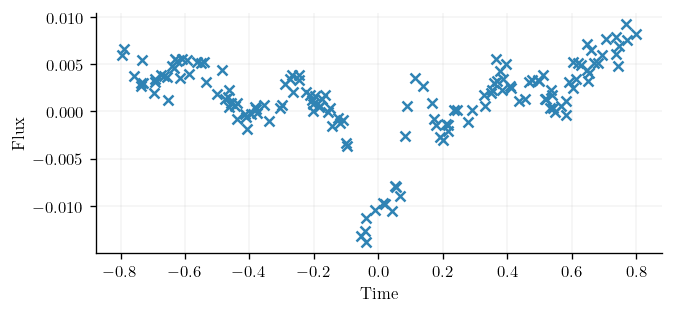

In [4]:
white_noise_std = 0.001
phi = 0
(
    t_train,
    lc_train,
    train_mask,
    t,
    lightcurve,
    systematics,
    noise,
    mask,
) = calculate_example_lightcurve(noise_std=white_noise_std, phi=phi)

noise_std = white_noise_std / jnp.sqrt(1 - phi**2)

plt.scatter(t_train, lc_train)
plt.ylabel("Flux")
plt.xlabel("Time")
plt.savefig("../figures/001_kernelsearch/test_data.pdf")

## PERFORM KERNEL SEARCH

In [5]:
kernel_library = [
    Linear(),
    RBF(),
    OrnsteinUhlenbeck(),
    Periodic(),
    # PoweredExponential(power=jnp.array(0.8)),
]  # default powered exponential has infinite parameter for some reason

In [6]:
tree = KernelSearch(
    kernel_library,
    X=jnp.array(t_train[train_mask]),
    y=jnp.array(lc_train[train_mask]),
    obs_stddev=noise_std,
    verbosity=1,
)

model = tree.search(
    depth=7,
    n_leafs=4,
    patience=1,
).posterior

Fitting Layer 1: 100%|██████████| 4/4 [00:03<00:00,  1.03it/s]


Layer 1 || Current top AICs: [-1394.9594579872298, -1386.6622842026609, -1306.2319749199003, -717.041023824419]


Fitting Layer 2: 100%|██████████| 32/32 [00:47<00:00,  1.48s/it]


Layer 2 || Current top AICs: [-1405.2563923978, -1398.4281892951612, -1398.4281892951274, -1393.1879449876244]


Fitting Layer 3: 100%|██████████| 44/44 [02:59<00:00,  4.07s/it]


...

Layer 4 || Current top AICs: [-1419.7853696150287, -1419.785369614856, -1412.433808909399, -1412.433808909386]


Fitting Layer 5: 100%|██████████| 48/48 [03:11<00:00,  3.99s/it]


Layer 5 || Current top AICs: [-1417.7853696150314, -1417.7853696150132, -1417.785369615012, -1417.7853696148784]


Fitting Layer 6: 100%|██████████| 48/48 [03:57<00:00,  4.94s/it]

Layer 6 || Current top AICs: [-1417.7853696150319, -1415.785369615029, -1415.7853696150282, -1415.7853696150073]
No more improvements found! Terminating early..

Terminated on layer: 6.
Final log likelihood: 715.8926848075143
715.8926848075143
Final number of model parameter: 6


In [14]:
model_name = "gpmodel"
with open(f"../data/processed/toy_data/gp_models/{model_name}", "wb") as file:
    pickle.dump(model, file)
summary = kernel_summary(model, to_latex=False)

Kernel Summary

Kernel Structure: Periodic • Linear • Linear + Periodic

--------------------------------------------------------------------------------
Kernel               Property             Value                Trainable 
--------------------------------------------------------------------------------
Periodic            lengthscale          157.30415            True      

                    variance             0.000104435545       True      

                    period               18134.404            True      
--------------------------------------------------------------------------------
Linear              variance             1.0                  False     
--------------------------------------------------------------------------------
Linear              variance             1.0                  False     
--------------------------------------------------------------------------------
Periodic            lengthscale          0.21557741           True      

       

## PLOT GP PREDICTION

In [ ]:
# calculate mean and std of predictive distribution
latent_dist = model(
    t.reshape(-1, 1),
    train_data=gpx.Dataset(X=t[mask].reshape(-1, 1), y=lc_train[mask].reshape(-1, 1)),
)
predictive_dist = model.likelihood(latent_dist)

predictive_mean = predictive_dist.mean()
predictive_std = predictive_dist.stddev()

In [ ]:
fig, ax = plt.subplots()
ax.scatter(t_train, lc_train, label="Observations", color=cols[0], alpha=0.5)
ax.plot(
    t,
    lightcurve + systematics,
    label="Light Curve + Systematics",
    color=cols[0],
    linestyle="--",
    linewidth=2,
)
ax.plot(
    t,
    systematics,
    label="Systematics",
    color=cols[0],
    linestyle="-",
    linewidth=2,
)

ax.plot(
    t,
    predictive_mean,
    label="Predictive mean",
    color=cols[1],
)
ax.fill_between(
    t,
    predictive_mean - 2 * predictive_std,
    predictive_mean + 2 * predictive_std,
    alpha=0.2,
    label="Two sigma",
    color=cols[1],
)
ax.plot(
    t,
    predictive_mean - 2 * predictive_std,
    linestyle="--",
    linewidth=1,
    color=cols[1],
)
ax.plot(
    t,
    predictive_mean + 2 * predictive_std,
    linestyle="--",
    linewidth=1,
    color=cols[1],
)

ax.fill_between(
    t,
    -0.015,
    0.012,
    where=~mask,
    alpha=0.3,
    color="grey",
    zorder=0,
)
ax.set_ylim([-0.015, 0.012])
ax.set_ylabel("Flux")
ax.set_xlabel("Time")

ax.legend(loc="center left", bbox_to_anchor=(0, 0.23))
plt.savefig("../figures/001_kernelsearch/gp_fit.pdf")

## PLOT KERNEL CONTRIBUTIONS

In [ ]:
model2 = model.likelihood * gpx.gps.Prior(
    mean_function=model.prior.mean_function,
    kernel=model.prior.kernel.kernels[0],  # type: ignore
)
model3 = model.likelihood * gpx.gps.Prior(
    mean_function=model.prior.mean_function,
    kernel=model.prior.kernel.kernels[1],  # type: ignore
)

In [ ]:
latent_dist2 = model2(
    t.reshape(-1, 1),
    train_data=gpx.Dataset(X=t[mask].reshape(-1, 1), y=lc_train[mask].reshape(-1, 1)),
)
predictive_dist2 = model2.likelihood(latent_dist2)
predictive_mean2 = predictive_dist2.mean()

latent_dist3 = model3(
    t.reshape(-1, 1),
    train_data=gpx.Dataset(X=t[mask].reshape(-1, 1), y=lc_train[mask].reshape(-1, 1)),
)
predictive_dist3 = model3.likelihood(latent_dist3)
predictive_mean3 = predictive_dist3.mean()

fig, ax = plt.subplots()

ax.plot(
    t,
    predictive_mean2,
    label="Kernel Term 1 (Periodic • Linear • Linear)",
    color=cols[0],
)

ax.plot(
    t,
    predictive_mean3,
    label="Kernel Term 2 (Periodic)",
    color=cols[1],
)

ax.set_ylim([-0.015, 0.012])
ax.set_ylabel("Kernel Contribution")
ax.set_xlabel("Time")

ax.legend(loc="center left", bbox_to_anchor=(0, 0.23))
plt.savefig("../figures/001_kernelsearch/gp_fit_decompostion.pdf")